# **Meagelleine Rose Sionosa**
## BSCS 3A-AI

# Fine-Tuning a Pretrained LLM for Domain-Specific Text Classification

---

## Overview

This notebook demonstrates how to fine-tune a pretrained Large Language Model (LLM) for a domain-specific NLP task using the Hugging Face `transformers` library.

| Step | Detail |
|------|--------|
| **Task** | Multi-class Text Classification |
| **Domain** | Mental Health / Clinical Psychology |
| **Dataset** | [`dair-ai/emotion`](https://huggingface.co/datasets/dair-ai/emotion) — English Twitter messages labeled with 6 basic emotions |
| **Pretrained LLM** | `distilbert-base-uncased` (DistilBERT, 66M params) |
| **Evaluation Metrics** | Accuracy, Weighted F1-Score, Classification Report |

### Why this domain?
Emotion recognition from text is a clinically relevant NLP task used in mental health screening, sentiment-aware chatbots, and crisis detection systems. The `dair-ai/emotion` dataset provides clean, real-world Twitter data with 6 emotion labels: **sadness, joy, love, anger, fear, surprise**.

---

## Step 1 — Identify the Task

**Task:** Sequence Classification (multi-class, single-label)

Given a short English text (a tweet), the model must assign it to **one** of six emotion categories:

| ID | Label    | Description                        |
|----|----------|------------------------------------|
| 0  | sadness  | Expressions of grief or sorrow     |
| 1  | joy      | Happiness, positivity              |
| 2  | love     | Affection, warmth                  |
| 3  | anger    | Frustration, rage                  |
| 4  | fear     | Anxiety, dread                     |
| 5  | surprise | Astonishment, unexpectedness       |

This is a **fine-tuning** scenario: we start from a general-purpose language model (DistilBERT) and adapt it to this specialized classification task.

## Step 2 — Identify the Domain

**Domain:** Mental Health & Affective Computing

**Dataset:** [`dair-ai/emotion`](https://huggingface.co/datasets/dair-ai/emotion)
- 16,000 training samples, 2,000 validation, 2,000 test
- Source: English tweets collected and labeled by [Saravia et al. (2018)](https://aclanthology.org/D18-1404/)
- Balanced across 6 classes
- Clean, tokenizable short texts (avg ~12 words)

**Why DistilBERT on emotion data?**
DistilBERT was pretrained on BookCorpus + English Wikipedia (general domain). By fine-tuning on Twitter emotion data, we inject **affective domain knowledge** — teaching the model to recognize linguistic cues of emotions in informal social media text.

## Step 3 — Identify the LLM

**Model:** [`distilbert-base-uncased`](https://huggingface.co/distilbert-base-uncased)

| Property              | Value                          |
|-----------------------|--------------------------------|
| Architecture          | DistilBERT (distilled BERT)    |
| Parameters            | ~66 million                    |
| Pretraining           | BookCorpus + Wikipedia (MLM)   |
| Speed vs BERT         | 60% faster, 40% smaller        |
| Max sequence length   | 512 tokens                     |
| Vocabulary size       | 30,522 WordPiece tokens        |

DistilBERT is ideal for educational fine-tuning experiments: it is small enough to train on CPU/single-GPU but retains ~97% of BERT's performance on downstream tasks.

## 📦 Install Dependencies

In [1]:
# Install required packages
!pip install -q transformers datasets evaluate accelerate scikit-learn seaborn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.4 MB/s eta 0:00:00


## 📚 Import Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    pipeline,
)
import evaluate
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully.")

All libraries imported successfully.


## 🗂️ Load and Explore the Dataset

In [3]:
# Load the dair-ai/emotion dataset from Hugging Face Hub
dataset = load_dataset("dair-ai/emotion")

print("Dataset structure:")
print(dataset)
print("\nSample training example:")
print(dataset["train"][0])

README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Dataset structure:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

Sample training example:
{'text': 'i didnt feel humiliated', 'label': 0}


In [4]:
# Define label mappings
id2label = {
    0: "sadness",
    1: "joy",
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise",
}
label2id = {v: k for k, v in id2label.items()}

print("Label mappings:")
for k, v in id2label.items():
    print(f"  {k} → {v}")

Label mappings:
  0 → sadness
  1 → joy
  2 → love
  3 → anger
  4 → fear
  5 → surprise


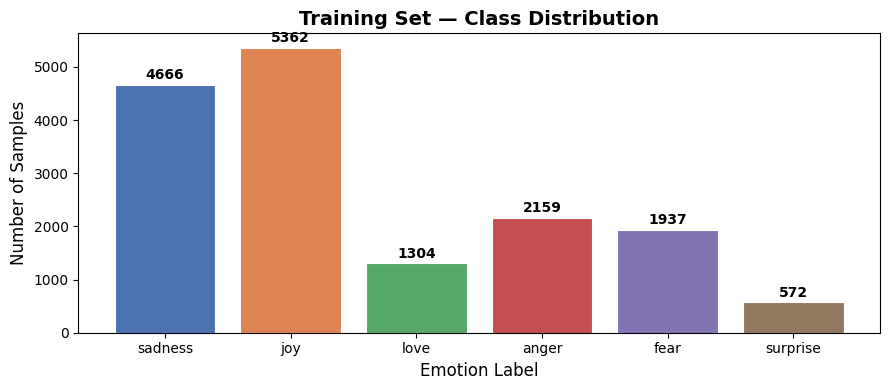

Class distribution saved.


In [5]:
# Visualize the class distribution in the training set
from collections import Counter

train_labels = dataset["train"]["label"]
label_counts = Counter(train_labels)

labels_sorted = [id2label[i] for i in sorted(label_counts.keys())]
counts_sorted = [label_counts[i] for i in sorted(label_counts.keys())]

colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860"]

plt.figure(figsize=(9, 4))
bars = plt.bar(labels_sorted, counts_sorted, color=colors, edgecolor='white', linewidth=0.8)
plt.title("Training Set — Class Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Emotion Label", fontsize=12)
plt.ylabel("Number of Samples", fontsize=12)
for bar, count in zip(bars, counts_sorted):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             str(count), ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=120)
plt.show()
print("Class distribution saved.")

In [6]:
# Print a few examples from each class
print("Sample texts per emotion:\n")
for label_id, label_name in id2label.items():
    examples = [ex["text"] for ex in dataset["train"] if ex["label"] == label_id][:2]
    print(f"[{label_name.upper()}]")
    for ex in examples:
        print(f"  • {ex}")
    print()

Sample texts per emotion:

[SADNESS]
  • i didnt feel humiliated
  • i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake

[JOY]
  • i have been with petronas for years i feel that petronas has performed well and made a huge profit
  • i do feel that running is a divine experience and that i can expect to have some type of spiritual encounter

[LOVE]
  • i am ever feeling nostalgic about the fireplace i will know that it is still on the property
  • i feel romantic too

[ANGER]
  • im grabbing a minute to post i feel greedy wrong
  • i am feeling grouchy

[FEAR]
  • i feel as confused about life as a teenager or as jaded as a year old man
  • i now feel compromised and skeptical of the value of every unit of work i put in

[SURPRISE]
  • ive been taking or milligrams or times recommended amount and ive fallen asleep a lot faster but i also feel like so funny
  • i have seen heard and read over the past couple of days i am left fee

## Step 4 — Configuration & Fine-Tuning Setup

Here we configure:
1. The tokenizer (how raw text is converted to model input)
2. The model head (classification layer on top of DistilBERT)
3. The `TrainingArguments` (hyperparameters for the fine-tuning run)

In [7]:
# ── Configuration ──────────────────────────────────────────────────────
MODEL_NAME       = "distilbert-base-uncased"   # Pretrained base model
NUM_LABELS       = 6                           # Number of emotion classes
MAX_LENGTH       = 128                         # Max token length (tweets are short)
BATCH_SIZE       = 16                          # Batch size for train & eval
LEARNING_RATE    = 2e-5                        # Standard fine-tuning LR for BERT-family
WEIGHT_DECAY     = 0.01                        # L2 regularization
NUM_EPOCHS       = 4                           # Enough for small dataset convergence
OUTPUT_DIR       = "./emotion-distilbert"      # Where checkpoints are saved
FINAL_MODEL_DIR  = "./emotion-distilbert-final" # Final saved model
# ───────────────────────────────────────────────────────────────────────

print("Fine-Tuning Configuration:")
config_summary = {
    "Base model"     : MODEL_NAME,
    "Task"           : "Multi-class text classification (6 emotions)",
    "Dataset"        : "dair-ai/emotion",
    "Max seq length" : MAX_LENGTH,
    "Batch size"     : BATCH_SIZE,
    "Learning rate"  : LEARNING_RATE,
    "Weight decay"   : WEIGHT_DECAY,
    "Epochs"         : NUM_EPOCHS,
}
for k, v in config_summary.items():
    print(f"  {k:<20}: {v}")

Fine-Tuning Configuration:
  Base model          : distilbert-base-uncased
  Task                : Multi-class text classification (6 emotions)
  Dataset             : dair-ai/emotion
  Max seq length      : 128
  Batch size          : 16
  Learning rate       : 2e-05
  Weight decay        : 0.01
  Epochs              : 4


In [8]:
# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"   Tokenizer loaded: {MODEL_NAME}")
print(f"   Vocabulary size: {tokenizer.vocab_size:,}")

# Example tokenization
sample = "I feel so overwhelmed and anxious about everything."
tokens = tokenizer(sample, truncation=True, max_length=MAX_LENGTH)
print(f"\nSample text: '{sample}'")
print(f"Token IDs: {tokens['input_ids']}")
print(f"Decoded tokens: {tokenizer.convert_ids_to_tokens(tokens['input_ids'])}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

   Tokenizer loaded: distilbert-base-uncased
   Vocabulary size: 30,522

Sample text: 'I feel so overwhelmed and anxious about everything.'
Token IDs: [101, 1045, 2514, 2061, 13394, 1998, 11480, 2055, 2673, 1012, 102]
Decoded tokens: ['[CLS]', 'i', 'feel', 'so', 'overwhelmed', 'and', 'anxious', 'about', 'everything', '.', '[SEP]']


In [9]:
# Tokenize the entire dataset
def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
    )

tokenized_dataset = dataset.map(tokenize_function, batched=True)
print("Dataset tokenized.")
print(f"   Train samples : {len(tokenized_dataset['train']):,}")
print(f"   Valid samples : {len(tokenized_dataset['validation']):,}")
print(f"   Test samples  : {len(tokenized_dataset['test']):,}")

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Dataset tokenized.
   Train samples : 16,000
   Valid samples : 2,000
   Test samples  : 2,000


In [10]:
# Dynamic padding — pads each batch to the longest sequence in that batch
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Load the pretrained model with a classification head
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id,
)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f" Model loaded: {MODEL_NAME}")
print(f"   Total parameters      : {total_params:,}")
print(f"   Trainable parameters  : {trainable_params:,}")
print(f"   Classification head   : 6-way softmax (one per emotion)")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


 Model loaded: distilbert-base-uncased
   Total parameters      : 66,958,086
   Trainable parameters  : 66,958,086
   Classification head   : 6-way softmax (one per emotion)


In [11]:
# Load evaluation metrics
accuracy_metric = evaluate.load("accuracy")
f1_metric       = evaluate.load("f1")

def compute_metrics(eval_pred):
    """Compute accuracy and weighted F1-score for each evaluation epoch."""
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=predictions, references=labels)["accuracy"]
    f1  = f1_metric.compute(predictions=predictions, references=labels, average="weighted")["f1"]
    return {
        "accuracy"   : round(acc, 4),
        "f1_weighted": round(f1,  4),
    }

print("Metrics configured: accuracy + weighted F1-score")

Metrics configured: accuracy + weighted F1-score


In [12]:
# Define TrainingArguments — full fine-tuning configuration
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,

    # ── Learning schedule ────────────────────────────────────────────────
    learning_rate=LEARNING_RATE,       # Peak LR (linear warmup + decay)
    weight_decay=WEIGHT_DECAY,         # L2 regularization on all weights
    num_train_epochs=NUM_EPOCHS,       # Number of full passes over training data

    # ── Batch sizes ──────────────────────────────────────────────────────
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,

    # ── Evaluation & checkpointing ───────────────────────────────────────
    eval_strategy="epoch",             # Evaluate after every epoch
    save_strategy="epoch",             # Save checkpoint after every epoch
    load_best_model_at_end=True,       # Restore best checkpoint at the end
    metric_for_best_model="f1_weighted",  # Use F1 to pick the best model
    greater_is_better=True,

    # ── Logging ──────────────────────────────────────────────────────────
    logging_steps=50,
    report_to="none",                  # Disable W&B / MLflow
)

print("TrainingArguments configured.")

TrainingArguments configured.


In [13]:
# Instantiate the Hugging Face Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Trainer ready. Starting fine-tuning...")

Trainer ready. Starting fine-tuning...


In [14]:
# ── Fine-Tuning ─────────────────────────────────────────────────────────
train_result = trainer.train()

print("\nFine-tuning complete!")
print(f"   Total train runtime : {train_result.metrics['train_runtime']:.1f}s")
print(f"   Samples per second  : {train_result.metrics['train_samples_per_second']:.1f}")
print(f"   Final train loss    : {train_result.metrics['train_loss']:.4f}")

Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted
1,0.249818,0.208101,0.927000,0.927400
2,0.154192,0.170375,0.933000,0.932200
3,0.098640,0.168448,0.936000,0.936400
4,0.059609,0.163292,0.941500,0.941500


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



Fine-tuning complete!
   Total train runtime : 425.5s
   Samples per second  : 150.4
   Final train loss    : 0.2046


## Step 5 — Evaluation

We evaluate on three levels:
1. **Validation set metrics** — accuracy and weighted F1 across all epochs
2. **Test set classification report** — per-class precision, recall, F1
3. **Confusion matrix** — visualize misclassifications
4. **Live inference demo** — run the fine-tuned model on new sentences

In [15]:
# ── 5.1 Validation set evaluation (best checkpoint) ─────────────────────
from transformers import Trainer
from transformers.utils.notebook import NotebookProgressCallback

eval_trainer = Trainer(
    model=trainer.model,
    args=training_args,
    eval_dataset=tokenized_dataset["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# Remove notebook progress callback that requires on_train_begin
eval_trainer.remove_callback(NotebookProgressCallback)

val_metrics = eval_trainer.evaluate()
print("Validation Set Metrics (best checkpoint):")
print(f"  Accuracy          : {val_metrics['eval_accuracy']:.4f}")
print(f"  Weighted F1-Score : {val_metrics['eval_f1_weighted']:.4f}")
print(f"  Eval loss         : {val_metrics['eval_loss']:.4f}")

Validation Set Metrics (best checkpoint):
  Accuracy          : 0.9415
  Weighted F1-Score : 0.9415
  Eval loss         : 0.1633


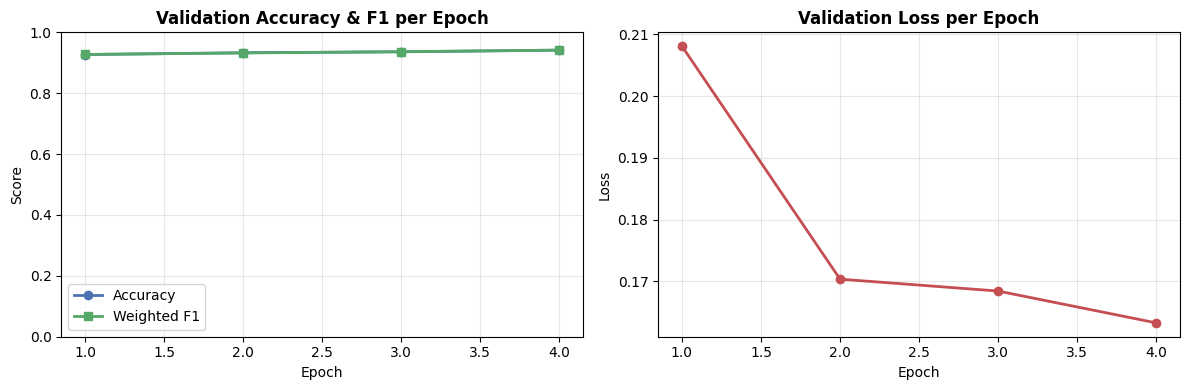

Training curves saved.


In [16]:
# ── 5.2 Plot training metrics across epochs ──────────────────────────────
log_history = trainer.state.log_history

# Extract per-epoch eval metrics
epochs, accuracies, f1_scores, eval_losses = [], [], [], []
for entry in log_history:
    if "eval_accuracy" in entry:
        epochs.append(entry["epoch"])
        accuracies.append(entry["eval_accuracy"])
        f1_scores.append(entry["eval_f1_weighted"])
        eval_losses.append(entry["eval_loss"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy & F1
axes[0].plot(epochs, accuracies, marker='o', label="Accuracy", color="#4C72B0", linewidth=2)
axes[0].plot(epochs, f1_scores,  marker='s', label="Weighted F1", color="#55A868", linewidth=2)
axes[0].set_title("Validation Accuracy & F1 per Epoch", fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Eval loss
axes[1].plot(epochs, eval_losses, marker='o', color="#C44E52", linewidth=2)
axes[1].set_title("Validation Loss per Epoch", fontweight='bold')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=120)
plt.show()
print("Training curves saved.")

In [17]:
# ── 5.3 Test set predictions ─────────────────────────────────────────────
test_output = trainer.predict(tokenized_dataset["test"])
test_preds  = np.argmax(test_output.predictions, axis=-1)
test_labels = test_output.label_ids

test_acc = accuracy_metric.compute(predictions=test_preds, references=test_labels)["accuracy"]
test_f1  = f1_metric.compute(predictions=test_preds, references=test_labels, average="weighted")["f1"]

print("=" * 50)
print("TEST SET EVALUATION RESULTS")
print("=" * 50)
print(f"  Accuracy           : {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"  Weighted F1-Score  : {test_f1:.4f}")
print("=" * 50)

TEST SET EVALUATION RESULTS
  Accuracy           : 0.9275 (92.75%)
  Weighted F1-Score  : 0.9273


In [18]:
# ── 5.4 Per-class Classification Report ─────────────────────────────────
label_names = [id2label[i] for i in range(NUM_LABELS)]

print("Per-Class Classification Report (Test Set):")
print(classification_report(test_labels, test_preds, target_names=label_names, digits=4))

Per-Class Classification Report (Test Set):
              precision    recall  f1-score   support

     sadness     0.9610    0.9742    0.9675       581
         joy     0.9546    0.9381    0.9463       695
        love     0.8059    0.8616    0.8328       159
       anger     0.9304    0.9236    0.9270       275
        fear     0.8860    0.9018    0.8938       224
    surprise     0.7719    0.6667    0.7154        66

    accuracy                         0.9275      2000
   macro avg     0.8850    0.8777    0.8805      2000
weighted avg     0.9276    0.9275    0.9273      2000



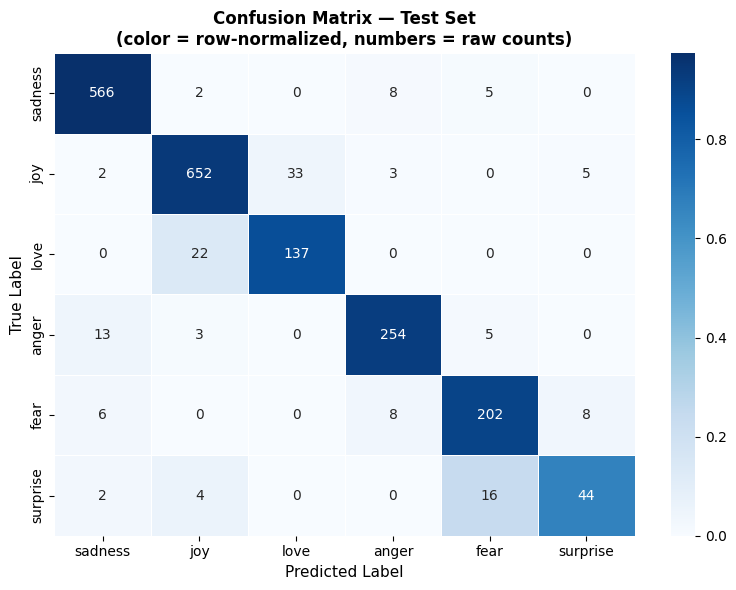

Confusion matrix saved.


In [19]:
# ── 5.5 Confusion Matrix ─────────────────────────────────────────────────
cm = confusion_matrix(test_labels, test_preds)
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_normalized,
    annot=cm,             # Show raw counts
    fmt='d',
    cmap='Blues',
    xticklabels=label_names,
    yticklabels=label_names,
    linewidths=0.5,
    linecolor='white',
)
plt.title("Confusion Matrix — Test Set\n(color = row-normalized, numbers = raw counts)",
          fontsize=12, fontweight='bold')
plt.ylabel("True Label", fontsize=11)
plt.xlabel("Predicted Label", fontsize=11)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=120)
plt.show()
print("Confusion matrix saved.")

## 💾 Save the Fine-Tuned Model

In [20]:
# Save the best model and tokenizer to disk
trainer.save_model(FINAL_MODEL_DIR)
tokenizer.save_pretrained(FINAL_MODEL_DIR)

print(f"✅ Model and tokenizer saved to: {FINAL_MODEL_DIR}")
print("   Files saved:")
import os
for f in os.listdir(FINAL_MODEL_DIR):
    size = os.path.getsize(os.path.join(FINAL_MODEL_DIR, f))
    print(f"     {f:<35} ({size/1024:.1f} KB)")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model and tokenizer saved to: ./emotion-distilbert-final
   Files saved:
     training_args.bin                   (5.1 KB)
     model.safetensors                   (261567.3 KB)
     tokenizer.json                      (694.8 KB)
     config.json                         (0.9 KB)
     tokenizer_config.json               (0.3 KB)


## 🔍 Inference Demo — Using the Fine-Tuned Model

In [21]:
# Load fine-tuned model via Hugging Face pipeline (production-style inference)
emotion_classifier = pipeline(
    task="text-classification",
    model=FINAL_MODEL_DIR,
    tokenizer=FINAL_MODEL_DIR,
    return_all_scores=True,  # Return probability for all 6 labels
)

print("✅ Fine-tuned model loaded for inference.")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

✅ Fine-tuned model loaded for inference.


In [22]:
# Run inference on new, unseen sentences
test_sentences = [
    "I just got promoted at work and I can't stop smiling!",
    "The news broke my heart. I've been crying all day.",
    "I'm terrified of what might happen if this goes wrong.",
    "She gave me a hug and said she cared. I felt so warm.",
    "That driver cut me off and I nearly lost it.",
    "Wait — did that actually just happen? I can't believe it!",
]

print("Emotion Classification — Inference Demo")
print("=" * 70)

for sentence in test_sentences:
    raw = emotion_classifier(sentence, top_k=None)  # request all class scores

    # Handle both old/new pipeline output shapes
    if isinstance(raw, list) and len(raw) > 0 and isinstance(raw[0], list):
        results = raw[0]          # old shape: [[{...}, ...]]
    else:
        results = raw             # new shape: [{...}, ...]

    results_sorted = sorted(results, key=lambda x: x["score"], reverse=True)
    top = results_sorted[0]

    print(f"\nTEXT  : {sentence}")
    print(f"PREDICTION: {top['label'].upper()} (confidence: {top['score']*100:.1f}%)")
    print("All scores:")
    for r in results_sorted:
        bar = "█" * int(r["score"] * 30)
        print(f"  {r['label']:<10}: {r['score']*100:5.1f}% {bar}")

Emotion Classification — Inference Demo

TEXT  : I just got promoted at work and I can't stop smiling!
PREDICTION: JOY (confidence: 99.8%)
All scores:
  joy       :  99.8% █████████████████████████████
  anger     :   0.1% 
  surprise  :   0.0% 
  love      :   0.0% 
  sadness   :   0.0% 
  fear      :   0.0% 

TEXT  : The news broke my heart. I've been crying all day.
PREDICTION: SADNESS (confidence: 99.1%)
All scores:
  sadness   :  99.1% █████████████████████████████
  fear      :   0.5% 
  anger     :   0.3% 
  joy       :   0.0% 
  surprise  :   0.0% 
  love      :   0.0% 

TEXT  : I'm terrified of what might happen if this goes wrong.
PREDICTION: FEAR (confidence: 99.9%)
All scores:
  fear      :  99.9% █████████████████████████████
  surprise  :   0.0% 
  anger     :   0.0% 
  sadness   :   0.0% 
  joy       :   0.0% 
  love      :   0.0% 

TEXT  : She gave me a hug and said she cared. I felt so warm.
PREDICTION: LOVE (confidence: 99.0%)
All scores:
  love      :  99.0% ████████

---
## 🔭 Word Embedding Visualization with PCA

In this section, we extract the **token embeddings** from the fine-tuned DistilBERT model's embedding layer for 20+ emotionally meaningful words, then reduce them to 2D using **Principal Component Analysis (PCA)** for visualization.

### Why PCA on word embeddings?
- DistilBERT represents each token as a **768-dimensional vector**
- Words with similar meaning/context cluster together in this high-dimensional space
- PCA compresses those 768 dimensions down to 2, preserving as much variance as possible
- The scatter plot reveals **semantic relationships** learned by the model

> Words colored by their associated emotion category. Clusters indicate the model has learned meaningful emotional distinctions.

In [23]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA
from transformers import AutoTokenizer, AutoModel

# ── 1. Define 20+ emotionally meaningful words grouped by emotion ────────
emotion_words = {
    "sadness" : ["grief", "tears", "sorrow", "lonely", "hopeless", "depressed"],
    "joy"     : ["happy", "cheerful", "excited", "elated", "wonderful", "bliss"],
    "love"    : ["adore", "affection", "tender", "cherish", "warmth"],
    "anger"   : ["furious", "rage", "hostile", "irritated", "outraged"],
    "fear"    : ["terrified", "anxious", "dread", "panic", "horror"],
    "surprise": ["astonished", "shocked", "amazed", "stunned", "unexpected"],
}

# Flatten to (word, emotion) pairs
words, word_labels = [], []
for emotion, wlist in emotion_words.items():
    for w in wlist:
        words.append(w)
        word_labels.append(emotion)

print(f"Total words for PCA: {len(words)}")
print("Words:", words)

Total words for PCA: 32
Words: ['grief', 'tears', 'sorrow', 'lonely', 'hopeless', 'depressed', 'happy', 'cheerful', 'excited', 'elated', 'wonderful', 'bliss', 'adore', 'affection', 'tender', 'cherish', 'warmth', 'furious', 'rage', 'hostile', 'irritated', 'outraged', 'terrified', 'anxious', 'dread', 'panic', 'horror', 'astonished', 'shocked', 'amazed', 'stunned', 'unexpected']


In [24]:
# ── 2. Extract embeddings from the fine-tuned model's embedding layer ────
# We use the embedding layer (NOT the full forward pass) to get static
# token vectors that reflect the model's learned representation space.

# Load the fine-tuned model's base (without classification head)
embed_tokenizer = AutoTokenizer.from_pretrained(FINAL_MODEL_DIR)
embed_model     = AutoModel.from_pretrained(FINAL_MODEL_DIR)
embed_model.eval()

vectors = []

with torch.no_grad():
    for word in words:
        # Tokenize single word
        inputs = embed_tokenizer(word, return_tensors="pt")
        outputs = embed_model(**inputs)
        # Use the [CLS] token hidden state as the word's contextual vector
        cls_vector = outputs.last_hidden_state[:, 0, :].squeeze().numpy()
        vectors.append(cls_vector)

vectors = np.array(vectors)
print(f"Embedding matrix shape: {vectors.shape}")
print(f"Each word → {vectors.shape[1]}-dimensional vector")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: ./emotion-distilbert-final
Key                   | Status     |  | 
----------------------+------------+--+-
pre_classifier.weight | UNEXPECTED |  | 
classifier.bias       | UNEXPECTED |  | 
pre_classifier.bias   | UNEXPECTED |  | 
classifier.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding matrix shape: (32, 768)
Each word → 768-dimensional vector


In [25]:
# ── 3. Reduce to 2D with PCA ─────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(vectors)

explained = pca.explained_variance_ratio_
print(f"PCA Explained Variance:")
print(f"  PC1: {explained[0]*100:.2f}%")
print(f"  PC2: {explained[1]*100:.2f}%")
print(f"  Total: {sum(explained)*100:.2f}%")

PCA Explained Variance:
  PC1: 26.52%
  PC2: 18.21%
  Total: 44.73%


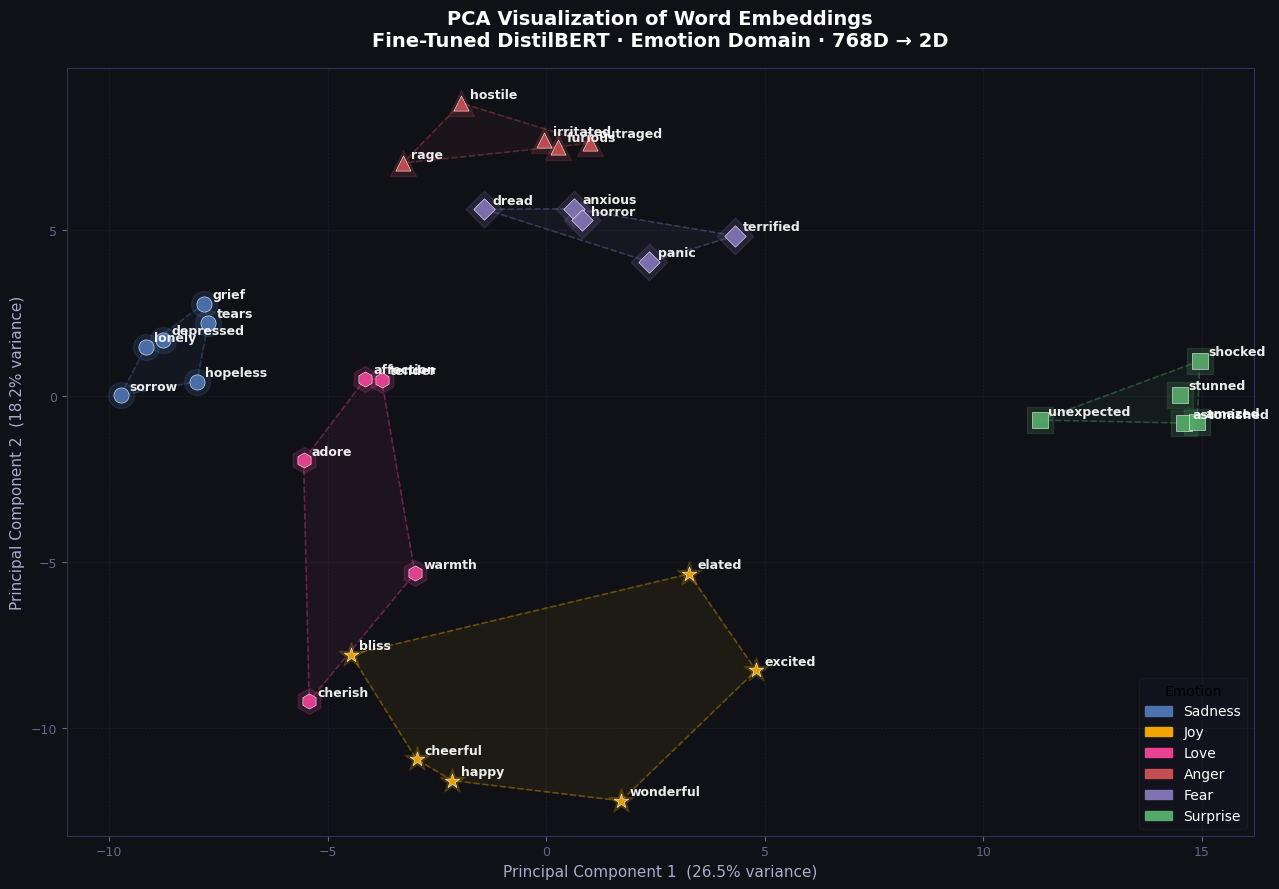

✅ PCA plot saved as pca_word_embeddings.png


In [26]:
# ── 4. Plot PCA Scatter ──────────────────────────────────────────────────

# Color palette — one distinct color per emotion
PALETTE = {
    "sadness" : "#4C72B0",   # muted blue
    "joy"     : "#F0A500",   # golden yellow
    "love"    : "#E84393",   # deep pink
    "anger"   : "#C44E52",   # brick red
    "fear"    : "#8172B2",   # violet
    "surprise": "#55A868",   # green
}
MARKERS = {
    "sadness" : "o",
    "joy"     : "*",
    "love"    : "h",
    "anger"   : "^",
    "fear"    : "D",
    "surprise": "s",
}

fig, ax = plt.subplots(figsize=(13, 9))
fig.patch.set_facecolor("#0F1117")
ax.set_facecolor("#0F1117")

# Draw subtle grid
ax.grid(color='#2a2a3a', linestyle='--', linewidth=0.5, alpha=0.6)
ax.set_axisbelow(True)

# Plot each word
for i, (word, label) in enumerate(zip(words, word_labels)):
    x, y = coords[i]
    color  = PALETTE[label]
    marker = MARKERS[label]

    # Glow effect: translucent large scatter behind the main point
    ax.scatter(x, y, s=350, color=color, alpha=0.18, marker=marker)
    ax.scatter(x, y, s=120, color=color, alpha=0.95, marker=marker,
               edgecolors='white', linewidths=0.4, zorder=5)

    # Word annotation
    ax.annotate(
        word,
        xy=(x, y),
        xytext=(6, 4),
        textcoords='offset points',
        fontsize=9,
        color='white',
        fontweight='bold',
        alpha=0.92,
        zorder=6,
    )

# Draw convex hulls around each emotion cluster
from scipy.spatial import ConvexHull

for emotion, color in PALETTE.items():
    indices = [i for i, l in enumerate(word_labels) if l == emotion]
    pts = coords[indices]
    if len(pts) >= 3:
        try:
            hull = ConvexHull(pts)
            hull_pts = np.append(pts[hull.vertices], [pts[hull.vertices[0]]], axis=0)
            ax.fill(hull_pts[:, 0], hull_pts[:, 1], alpha=0.07, color=color, zorder=1)
            ax.plot(hull_pts[:, 0], hull_pts[:, 1], color=color,
                    alpha=0.35, linewidth=1.2, linestyle='--', zorder=2)
        except Exception:
            pass

# Legend
legend_handles = [
    mpatches.Patch(color=PALETTE[em], label=em.capitalize())
    for em in emotion_words.keys()
]
ax.legend(
    handles=legend_handles,
    loc='lower right',
    framealpha=0.2,
    facecolor='#1a1a2e',
    edgecolor='#444',
    fontsize=10,
    title="Emotion",
    title_fontsize=10,
    labelcolor='white',
)

# Axis labels and title
ax.set_xlabel(
    f"Principal Component 1  ({explained[0]*100:.1f}% variance)",
    color='#aaaacc', fontsize=11
)
ax.set_ylabel(
    f"Principal Component 2  ({explained[1]*100:.1f}% variance)",
    color='#aaaacc', fontsize=11
)
ax.tick_params(colors='#666688', labelsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor('#333355')

ax.set_title(
    "PCA Visualization of Word Embeddings\n"
    "Fine-Tuned DistilBERT · Emotion Domain · 768D → 2D",
    color='white', fontsize=14, fontweight='bold', pad=16
)

plt.tight_layout()
plt.savefig("pca_word_embeddings.png", dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print("✅ PCA plot saved as pca_word_embeddings.png")

In [27]:
# ── 5. Print PCA coordinates table for reference ─────────────────────────
print(f"{'Word':<14} {'Emotion':<10} {'PC1':>8} {'PC2':>8}")
print("-" * 44)
for i, (word, label) in enumerate(zip(words, word_labels)):
    print(f"{word:<14} {label:<10} {coords[i,0]:>8.4f} {coords[i,1]:>8.4f}")

Word           Emotion         PC1      PC2
--------------------------------------------
grief          sadness     -7.8354   2.7856
tears          sadness     -7.7339   2.2113
sorrow         sadness     -9.7411   0.0319
lonely         sadness     -9.1642   1.4867
hopeless       sadness     -7.9976   0.4287
depressed      sadness     -8.7733   1.6973
happy          joy         -2.1532 -11.5972
cheerful       joy         -2.9708 -10.9570
excited        joy          4.7988  -8.2756
elated         joy          3.2690  -5.3622
wonderful      joy          1.7119 -12.2088
bliss          joy         -4.4688  -7.8002
adore          love        -5.5553  -1.9358
affection      love        -4.1405   0.5251
tender         love        -3.7705   0.5011
cherish        love        -5.4268  -9.2061
warmth         love        -3.0070  -5.3441
furious        anger        0.2671   7.5226
rage           anger       -3.2819   7.0313
hostile        anger       -1.9439   8.8399
irritated      anger       -0.0